# 📊 Student Performance Clustering

## 🧠 Objective

Group students based on academic performance using K-Means clustering.

---

## ⚙️ Approach

* Applied One-Hot Encoding on categorical features
* Scaled data using StandardScaler
* Compared:

  * Full dataset
  * Scores-only dataset

---

## 📉 Key Findings

* Scores-only data gave better clustering (**Silhouette ≈ 0.47**)
* Full dataset performed poorly (**≈ 0.14**)
* Indicates categorical features added noise

---

## 📊 Clusters (Performance Levels)

* Cluster 3 → High performers
* Cluster 2 → Above average
* Cluster 0 → Average
* Cluster 4 → Below average
* Cluster 1 → Low performers

---

## 👥 Insight

* High-performing clusters had more female students
* Lowest cluster had more male students

---

## ✅ Conclusion

Clustering based on academic scores provides meaningful student segmentation, while adding categorical data reduces cluster quality.

---


In [153]:
import pandas as pd

df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [154]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


(1000, 8)

In [155]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,math score,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,72,72,74,False,True,False,False,False,True,False,False,False,False,True,True
1,69,90,88,False,False,True,False,False,False,False,False,True,False,True,False
2,90,95,93,False,True,False,False,False,False,False,True,False,False,True,True
3,47,57,44,True,False,False,False,False,False,False,False,False,False,False,True
4,76,78,75,True,False,True,False,False,False,False,False,True,False,True,True


In [156]:
df.shape

(1000, 8)

In [157]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

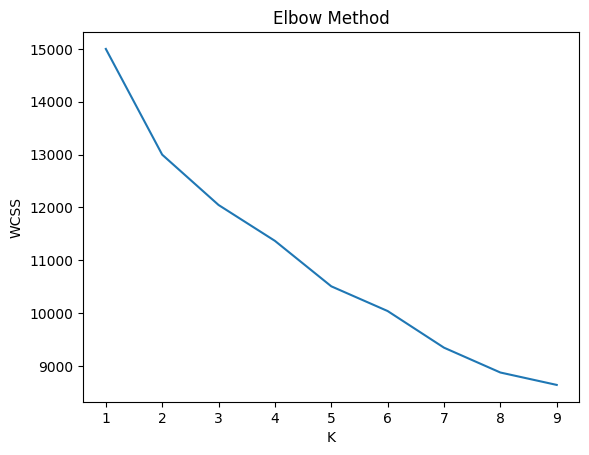

In [158]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 10):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

plt.plot(range(1, 10), wcss)
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [159]:
from sklearn.metrics import silhouette_score
df_scores = df[["math score", "reading score", "writing score"]]
df_full = df_encoded.copy()

scaler1 = StandardScaler()
scaled_scores = scaler1.fit_transform(df_scores)

scaler2 = StandardScaler()
scaled_full = scaler2.fit_transform(df_full)

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    
    y1 = kmeans.fit_predict(scaled_scores)
    y2 = kmeans.fit_predict(scaled_full)
    
    print(f"K={k}")
    print("Scores only:", silhouette_score(scaled_scores, y1))
    print("Full data:", silhouette_score(scaled_full, y2))
    print("-"*30)

K=2
Scores only: 0.47410805799442546
Full data: 0.12067903274278972
------------------------------
K=3
Scores only: 0.40599504065325176
Full data: 0.11645105204328393
------------------------------
K=4
Scores only: 0.3530512639720019
Full data: 0.12391953829045639
------------------------------
K=5
Scores only: 0.33065197797579354
Full data: 0.14697535011558727
------------------------------
K=6
Scores only: 0.31927905215476116
Full data: 0.14054833010691176
------------------------------
K=7
Scores only: 0.2984423997584124
Full data: 0.14946698803659844
------------------------------


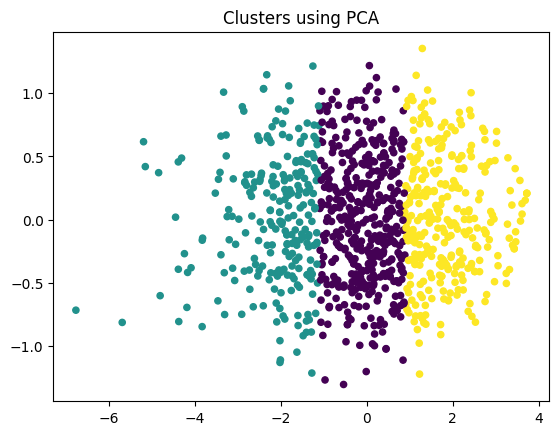

In [160]:
from sklearn.decomposition import PCA

kmeans = KMeans(n_clusters=3, random_state=42)
y1 = kmeans.fit_predict(scaled_scores)

# PCA only for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_scores)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y1, s=20)
plt.title("Clusters using PCA")
plt.show()

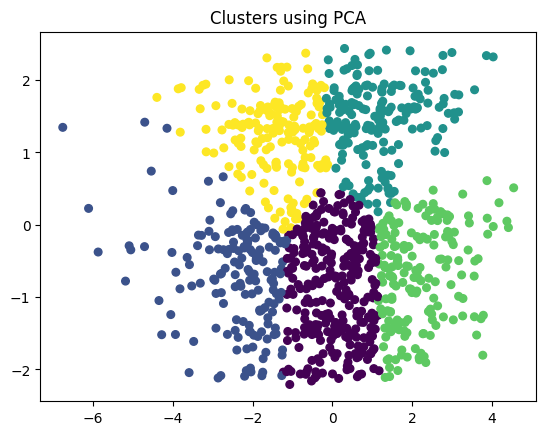

In [161]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_full)

kmeans = KMeans(n_clusters=5, random_state=42)
y2 = kmeans.fit_predict(X_pca)
df["cluster"] = y2

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y2, s=30)
plt.title("Clusters using PCA")
plt.show()

In [162]:
df["cluster_scores"] = y1  
df.groupby("cluster_scores")[["math score", "reading score", "writing score"]].mean()

,math score,reading score,writing score
cluster_scores,,,
0,65.338600,68.458239,67.821670
1,48.096386,50.670683,48.485944
2,81.714286,85.146104,84.207792


In [163]:
df["cluster_full"] = y2
df.groupby("cluster_full")[["math score", "reading score", "writing score"]].mean()

,math score,reading score,writing score
cluster_full,,,
0,67.277592,68.916388,68.367893
1,47.739130,49.453416,46.931677
2,73.115183,79.251309,79.157068
3,83.556180,85.932584,85.129213
4,55.257310,59.461988,57.216374


In [164]:
pd.crosstab(df["cluster_full"], df["gender"])

gender,female,male
cluster_full,,
0,137,162
1,57,104
2,136,55
3,100,78
4,88,83


In [165]:
pd.crosstab(df["cluster_full"], df["lunch"])

lunch,free/reduced,standard
cluster_full,,
0,96,203
1,97,64
2,39,152
3,33,145
4,90,81


In [166]:
pd.crosstab(df["cluster_full"], df["test preparation course"])

test preparation course,completed,none
cluster_full,,
0,98,201
1,23,138
2,102,89
3,101,77
4,34,137
